<a href="https://colab.research.google.com/github/vinay0145/-Data-Science-Capstone-Project-/blob/main/E_COMMERCE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Project Name:

👉 E-Commerce Customer Behavior Analysis using Python

In [ ]:
How can we analyze customer purchasing behavior in an e-commerce dataset using data preprocessing, scaling, and visualization techniques?

First 5 rows:
   InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       -----------

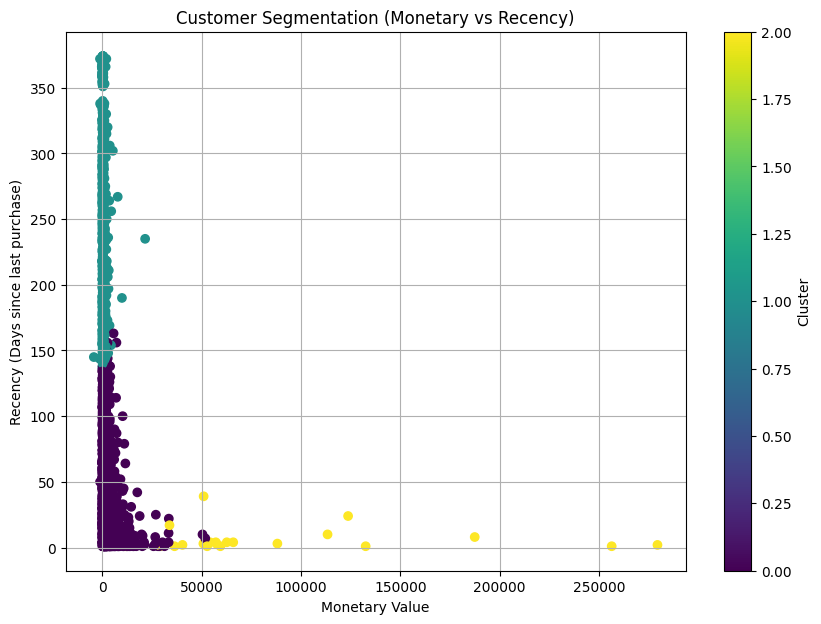

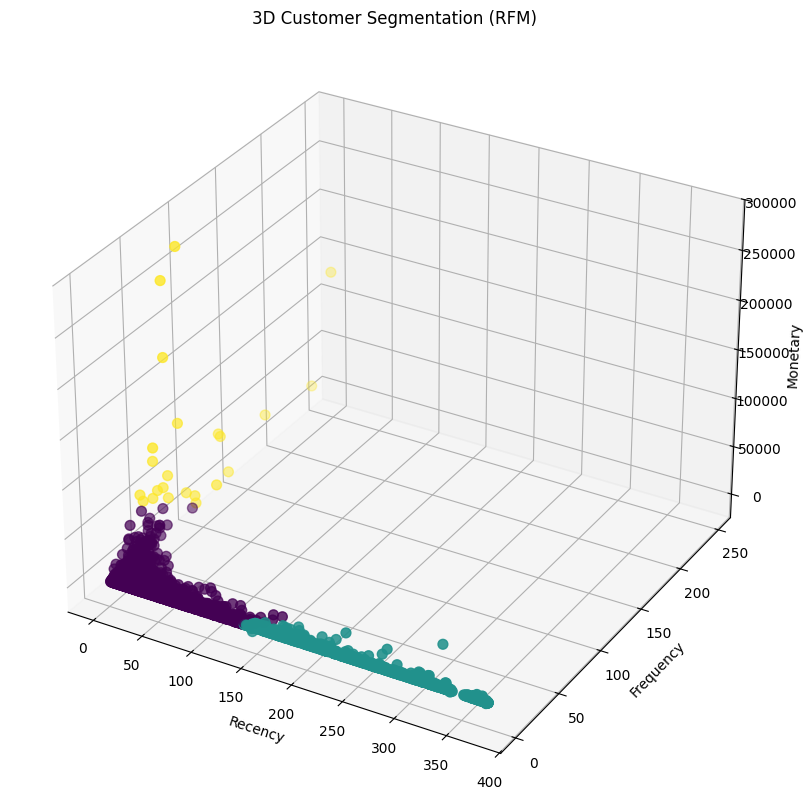

In [5]:
# Import Libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import zipfile
from datetime import timedelta

# Unzip the dataset if it's a zip file
with zipfile.ZipFile('data.csv.zip', 'r') as zip_ref:
    zip_ref.extractall('./')

# Load Dataset (update path if needed)
data = pd.read_csv('data.csv', encoding='latin1')

# Display basic info
print("First 5 rows:\n", data.head())
print("\nDataset Info:\n")
print(data.info())

# Check missing values
print("\nMissing Values:\n", data.isnull().sum())

# Drop missing values (simple method) - especially important for CustomerID for RFM analysis
data = data.dropna(subset=['CustomerID'])

# Calculate Revenue for each transaction
data['Revenue'] = data['Quantity'] * data['UnitPrice']

# Convert InvoiceDate to datetime objects
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

# Calculate a snapshot date for Recency calculation (one day after the last transaction)
snapshot_date = data['InvoiceDate'].max() + timedelta(days=1)

# Calculate RFM metrics
rfm_df = data.groupby('CustomerID').agg({
    'InvoiceDate': lambda date: (snapshot_date - date.max()).days, # Recency
    'InvoiceNo': lambda num: num.nunique(), # Frequency
    'Revenue': lambda price: price.sum() # Monetary
})

# Rename columns
rfm_df.columns = ['Recency', 'Frequency', 'Monetary']

# Reset index to make CustomerID a regular column
rfm_df = rfm_df.reset_index()

# Select RFM features for clustering
features = rfm_df[['Recency', 'Frequency', 'Monetary']]

# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

# Convert to DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=features.columns)

# Apply KMeans Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # Added n_init to suppress warning
scaled_df['Cluster'] = kmeans.fit_predict(scaled_df)

# Merge cluster back to original RFM dataframe for visualization with actual values
rfm_df['Cluster'] = scaled_df['Cluster']

# Visualization (2D) - Using Monetary and Recency for 2D plot
plt.figure(figsize=(10, 7))
plt.scatter(
    rfm_df['Monetary'],
    rfm_df['Recency'],
    c=rfm_df['Cluster'],
    cmap='viridis'
)

plt.xlabel('Monetary Value')
plt.ylabel('Recency (Days since last purchase)')
plt.title('Customer Segmentation (Monetary vs Recency)')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

# 3D Visualization - Using Recency, Frequency, Monetary
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    rfm_df['Recency'],
    rfm_df['Frequency'],
    rfm_df['Monetary'],
    c=rfm_df['Cluster'],
    cmap='viridis',
    s=50 # marker size
)

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

plt.title('3D Customer Segmentation (RFM)')
plt.show()